In [29]:
import util
import processUtil

from skimage import filters, morphology, measure, exposure
from skimage.segmentation import find_boundaries
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import joblib
import pandas as pd

# Get data

In [2]:
file_path = "processed_data/aliveData.joblib"

if os.path.exists(file_path):
    data = joblib.load(file_path)
else:
    data = util.getAliveData()
    joblib.dump(data, file_path)

# Get Mask (Segmentation)

In [3]:
# get masks and corrects for all alive data
# masks_corrected: index 0 = mask, index 1 = corrected
file_path = "processed_data/maskCorrect.joblib"

if os.path.exists(file_path):
    masks_corrected = joblib.load(file_path)
else:
    masks_corrected = []
    for i in range(len(data)):
        masks_corrected.append(processUtil.getSegments(data[i]))
    joblib.dump(masks_corrected, file_path)

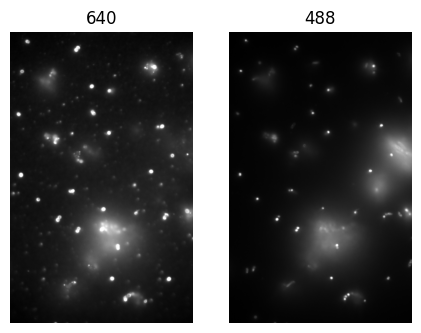

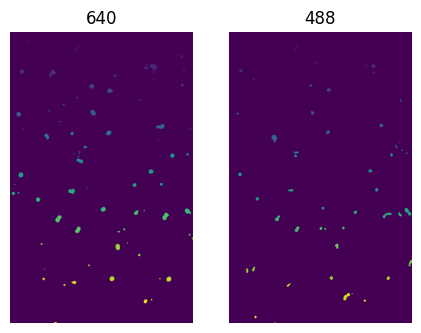

In [4]:
img_index = 133 # 0-133
util.printImg(data[img_index], "gray")
util.printMask(masks_corrected[img_index])

# Get Morphological Features

In [5]:
# get stats of each bateria for each img data
# stats: label, area, x, y, major_length, minor_length
file_path = "processed_data/maskSegmentStat.joblib"

if os.path.exists(file_path):
    stats = joblib.load(file_path)
else:
    stats = []
    for i in range(len(data)):
        stats.append(processUtil.getStats(masks_corrected[i], data[i]))
    joblib.dump(stats, file_path)

Image: pos_226


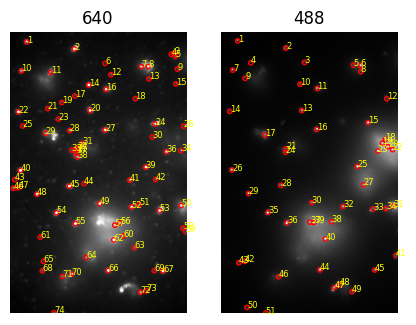

In [6]:
print(f"Image: {data[img_index][3]}")
util.printRegion(data[img_index], stats[img_index], map="gray")

In [7]:
print(stats[img_index][1])

    label   area           x           y  major_length  minor_length  \
0       1   38.0   39.421053   21.789474      8.328548      5.905849   
1       2   64.0  156.375000   39.140625     13.615157      6.427371   
2       3   25.0  201.640000   74.040000      9.923077      3.084372   
3       4    6.0   71.000000   75.166667      3.829708      1.885618   
4       5   17.0  320.705882   80.764706      5.848765      3.661203   
5       6   66.0  337.393939   81.712121      9.622454      8.743447   
6       7   39.0   27.282051   92.923077      7.534280      6.603839   
7       8   13.0  338.384615   96.615385      4.318667      3.679465   
8       9    9.0   57.111111  112.777778      4.312594      2.660929   
9      10   32.0  190.750000  127.187500      7.134661      5.790865   
10     11   62.0  232.854839  137.532258     10.256832      7.795266   
11     12   20.0  401.550000  162.300000      7.405734      3.416886   
12     13   52.0  195.019231  191.134615      9.714025      7.02

# Segmentation Comparison

In [9]:
file_path = "processed_data/compare.joblib"

if os.path.exists(file_path):
    compared = list(joblib.load(file_path))
else:
    compared = []
    for i in range(len(data)):
        shared, only_640, only_488, df_640_labeled, df_488_labeled, combined = processUtil.match_two_channels_greedy(
            df_a=stats[i][0],
            df_b=stats[i][1],
            tolerance=3,
            area_ratio_warning=3.0,
            channel_a_name="640",
            channel_b_name="488"
        )
        compared.append({"shared":shared, "only_640":only_640, "only_488":only_488, "df_640_labeled":df_640_labeled, "df_488_labeled":df_488_labeled, "combined":combined})
    joblib.dump(compared, file_path)

Image: pos_226


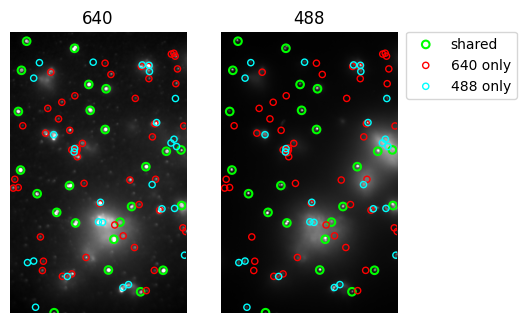

In [10]:
print(f"Image: {data[img_index][3]}")
util.printLabel(data[img_index], compared[img_index], map="gray")

Todo:
- count num of bateria:
```python
print(f"Segmentation complete.")
print(f"Masks shape: {masks.shape}")
print("Unique mask values:", np.unique(masks))
print("Number of objects:", len(np.unique(masks)) - 1)
```

Image: pos_54


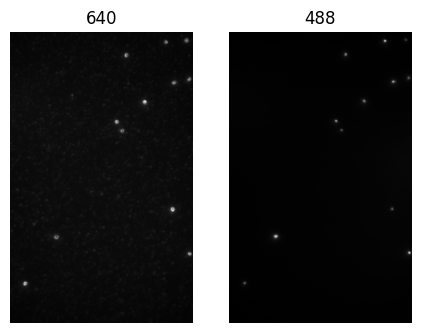

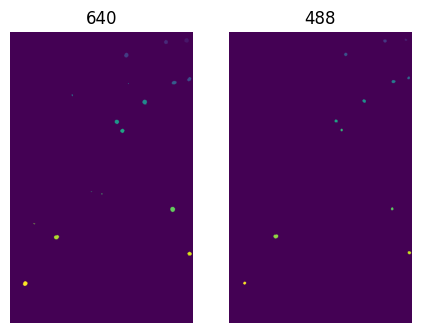

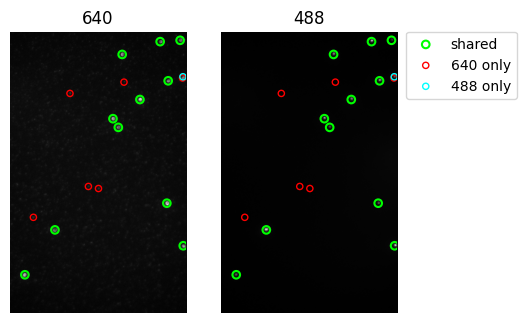

In [11]:
# testing
img_index = 11# 0-133
print(f"Image: {data[img_index][3]}")
util.printImg(data[img_index], "gray")
util.printMask(masks_corrected[img_index])
util.printLabel(data[img_index], compared[img_index], map="gray")

# Non-local Trainable Feature Extraction

In [19]:
processor = processUtil.extract_unified_features(compared[img_index]["combined"])

In [20]:
print(processor)

    in_640  in_488  major_length  minor_length  length_ratio  eccentricity  \
0     True    True     11.350414     10.016743  1.133144e+00      0.470312   
1     True    True     10.393742     10.166778  1.022324e+00      0.207837   
2     True    True     11.996931     11.120662  1.078797e+00      0.375163   
3     True    True     10.325645      9.718611  1.062461e+00      0.337819   
4     True    True      9.743684      9.312347  1.046319e+00      0.294240   
5     True    True     11.157126      9.588669  1.163574e+00      0.511269   
6     True    True     12.073263      9.539225  1.265644e+00      0.612963   
7     True    True      9.438855      8.923037  1.057807e+00      0.326053   
8     True    True     11.700733      7.936956  1.474209e+00      0.734758   
9     True    True     11.331349     10.630924  1.065886e+00      0.346129   
10    True    True      9.931389      8.722998  1.138529e+00      0.478062   
11    True   False     10.936410      7.828633  1.396976e+00    

In [38]:
extracted_features = []
for i in range(len(data)):
    clean_features = processUtil.extract_unified_features(compared[i]["combined"])
    extracted_features.append(clean_features)

extracted_features_df = pd.concat(extracted_features, ignore_index=True)

In [39]:
len(extracted_features_df)

14337

In [40]:
extracted_features_df

,in_640,in_488,major_length,minor_length,length_ratio,eccentricity,solidity,mean_intensity,max_intensity
0,True,True,9.712994,3.801798,2.554842,0.920215,0.933333,2037.250000,2566.0
1,True,True,26.041195,9.761133,2.667846,0.927092,0.894977,2783.846939,4540.0
2,True,True,11.077770,9.990160,1.108868,0.432111,0.977528,3057.678161,4199.0
3,True,True,14.810142,9.696974,1.527295,0.755844,0.923729,2714.834862,3977.0
4,True,True,14.634311,8.564695,1.708679,0.810855,0.923810,2349.762887,3456.0
...,...,...,...,...,...,...,...,...,...
14332,False,True,11.485116,5.008069,2.293322,0.899923,0.914894,16468.232558,21657.0
14333,False,True,11.418205,4.034714,2.829991,0.935488,0.900000,21182.861111,24302.0
14334,False,True,22.486524,8.585041,2.619268,0.924251,0.810976,38500.180451,65535.0
14335,False,True,2.000000,2.000000,1.000000,0.000000,1.000000,22360.000000,23017.0


# Saving all data and Images

## Save Final Extracted Features

In [43]:
path = os.getcwd()
results_dir = os.path.join(path, "results")
os.makedirs(results_dir, exist_ok=True)

extracted_features_df.to_csv(os.path.join(results_dir, "extracted_features.csv"), index=False)

# Save Images

In [42]:
import os
import matplotlib.pyplot as plt

path = os.getcwd()
results_dir = os.path.join(path, "results")
os.makedirs(results_dir, exist_ok=True)

old_show = plt.show
plt.show = lambda *args, **kwargs: None

for i in range(len(data)):
    file_name = data[i][3]
    print(file_name)

    sample_dir = os.path.join(results_dir, file_name)
    print(sample_dir)
    os.makedirs(sample_dir, exist_ok=True)

    util.printLabel(data[i], compared[i], map="gray")
    plt.savefig(os.path.join(sample_dir, "Label.png"), dpi=300, bbox_inches="tight")
    plt.close()

    util.printRegion(data[i], stats[i], map="gray")
    plt.savefig(os.path.join(sample_dir, "Region.png"), dpi=300, bbox_inches="tight")
    plt.close()

    util.printMask(masks_corrected[i])
    plt.savefig(os.path.join(sample_dir, "Mask.png"), dpi=300, bbox_inches="tight")
    plt.close()

    compared[i]['df_640_labeled'].to_csv(os.path.join(sample_dir, "df_640_labeled.csv"), index=False)
    compared[i]['df_488_labeled'].to_csv(os.path.join(sample_dir, "df_488_labeled.csv"), index=False)
    compared[i]['combined'].to_csv(os.path.join(sample_dir, "combined_640_488_classification.csv"), index=False)

plt.show = old_show

pos_43
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_43
pos_44
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_44
pos_45
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_45
pos_46
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_46
pos_47
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_47
pos_48
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_48
pos_49
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_49
pos_50
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_50
pos_51
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_51
pos_52
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_52
pos_53
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_53
pos_54
C:\Users\HP\Desktop\Warwick\Hackathon\BioImage\1-pipeline\results\pos_54
pos_55
C:\Users\HP\Desktop\Warwick\Hacka